In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/raw/train.csv")
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train.shape

(159571, 8)

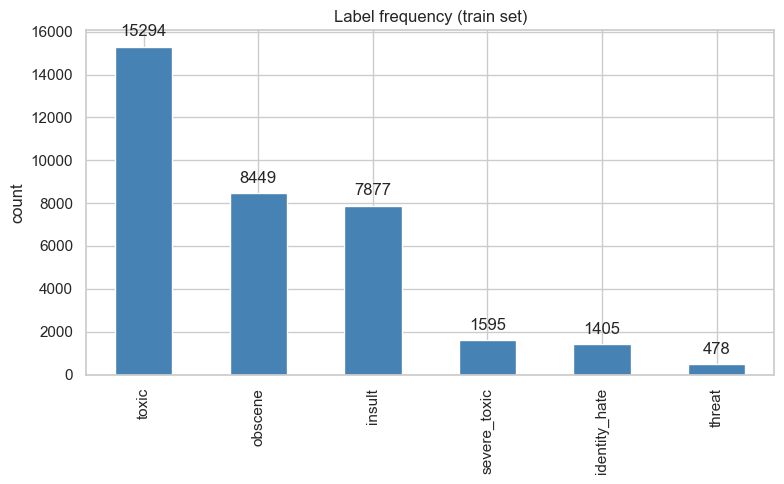

toxic            9.584448
obscene          5.294822
insult           4.936361
severe_toxic     0.999555
identity_hate    0.880486
threat           0.299553
dtype: float64

In [2]:
label_counts = train[label_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
label_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Label frequency (train set)")
ax.set_ylabel("count")
for i, v in enumerate(label_counts):
    ax.text(i, v + 500, str(v), ha="center")
plt.tight_layout()
plt.show()

label_counts / len(train) * 100

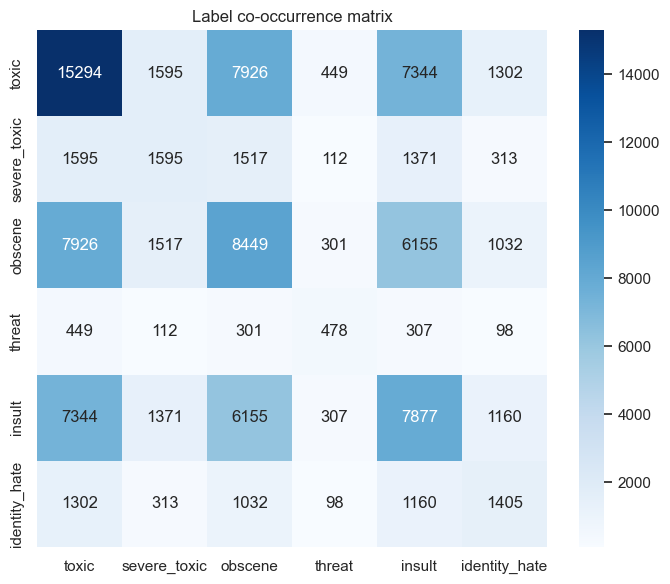

In [3]:
import numpy as np

co_occurrence = train[label_cols].T.dot(train[label_cols])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Label co-occurrence matrix")
plt.tight_layout()
plt.show()

In [4]:
train["num_labels"] = train[label_cols].sum(axis=1)
train["num_labels"].value_counts().sort_index()

num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

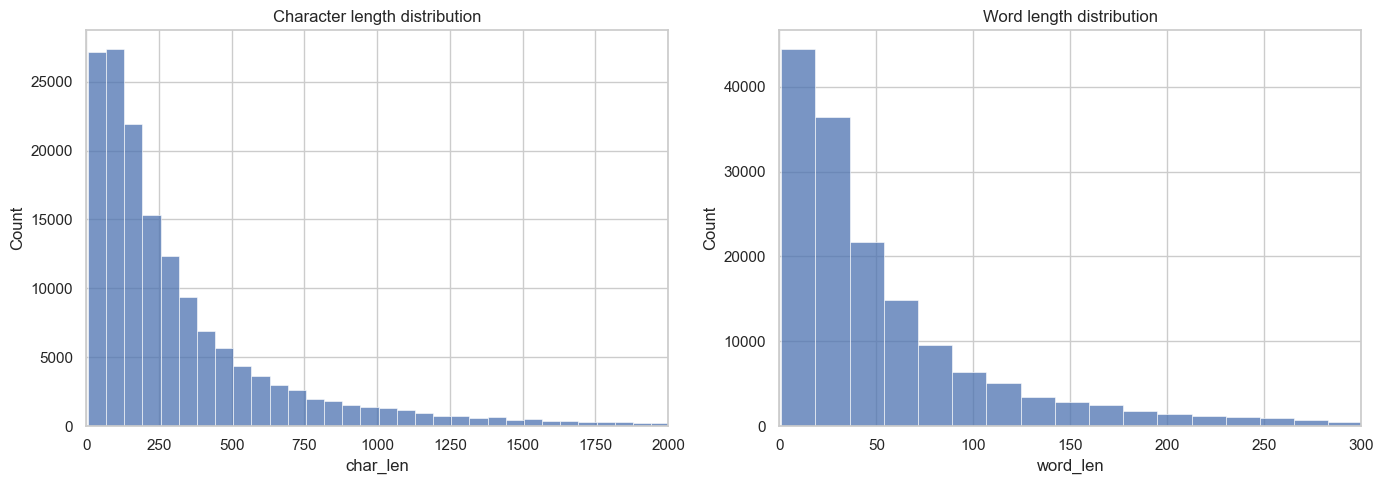

,char_len,word_len
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
90%,889.000000,152.000000
95%,1355.000000,230.000000
99%,3444.000000,567.000000
max,5000.000000,1411.000000


In [5]:
train["char_len"] = train["comment_text"].str.len()
train["word_len"] = train["comment_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train["char_len"], bins=80, ax=axes[0])
axes[0].set_title("Character length distribution")
axes[0].set_xlim(0, 2000)

sns.histplot(train["word_len"], bins=80, ax=axes[1])
axes[1].set_title("Word length distribution")
axes[1].set_xlim(0, 300)
plt.tight_layout()
plt.show()

train[["char_len", "word_len"]].describe(percentiles=[.5, .75, .9, .95, .99])

C:\Users\SUSHANTH\AppData\Local\Temp\ipykernel_17464\177987550.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["clean", "toxic (any label)"])


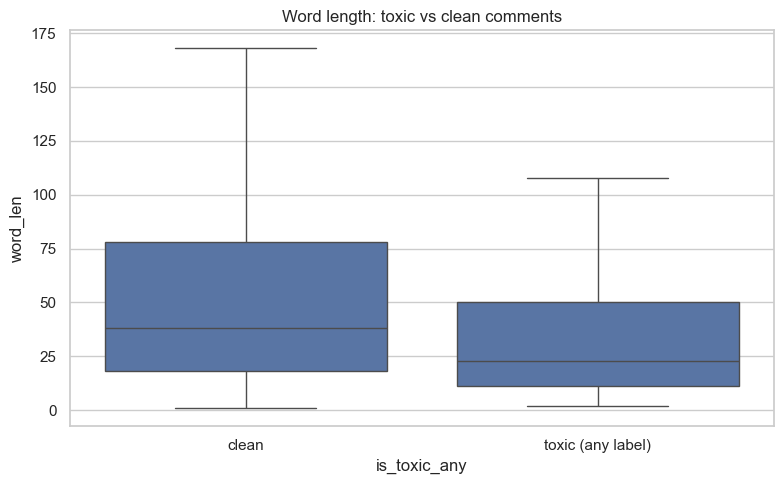

In [6]:
train["is_toxic_any"] = train["num_labels"] > 0

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=train, x="is_toxic_any", y="word_len", ax=ax, showfliers=False)
ax.set_title("Word length: toxic vs clean comments")
ax.set_xticklabels(["clean", "toxic (any label)"])
plt.tight_layout()
plt.show()

In [7]:
for label in label_cols:
    print(f"\n{'='*20} {label.upper()} examples {'='*20}")
    samples = train[train[label] == 1]["comment_text"].sample(2, random_state=42)
    for s in samples:
        print("-", s[:200].replace("\n", " "), "...")

print(f"\n{'='*20} CLEAN examples {'='*20}")
samples = train[train["num_labels"] == 0]["comment_text"].sample(3, random_state=42)
for s in samples:
    print("-", s[:200].replace("\n", " "), "...")


==================== TOXIC examples ====================
- Hi!   I wanna rape you! ...
- Terrorize  I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threatening people you bas ...

==================== SEVERE_TOXIC examples ====================
- "   WHAT  IN THE FUCK ARE YOU REFERRING TOO   I HAVE NO IDEA WHAT THE PISS YOU'RE REFERRING TOO, OR WHY YOU BOTHERED TO WRITE ME.  LISTEN I'VE ADDED PLENTY TO THESE PAGE INCLUDING A ""SMASHING"" ARTIC ...
- takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the  ...

==================== OBSCENE examples ====================
- You are an utter fucking faggot...u need a life outside of wikipedia...maybe a didlo fuk by ur mom? ...
- WTF!   u fckin faggot ass mutha fcker u jus re-did and del

In [8]:
summary = {
    "total_rows": len(train),
    "clean_rows": int((train["num_labels"] == 0).sum()),
    "label_counts": label_counts.to_dict(),
    "word_len_p95": float(train["word_len"].quantile(0.95)),
    "word_len_p99": float(train["word_len"].quantile(0.99)),
    "word_len_max": int(train["word_len"].max()),
}
summary

{'total_rows': 159571,
 'clean_rows': 143346,
 'label_counts': {'toxic': 15294,
  'obscene': 8449,
  'insult': 7877,
  'severe_toxic': 1595,
  'identity_hate': 1405,
  'threat': 478},
 'word_len_p95': 230.0,
 'word_len_p99': 567.0,
 'word_len_max': 1411}